# OpenVLA

OpenVLA 的贡献：<mark>**高效微调与部署方法**</mark>

OpenVLA 不是 RT-2 的复刻，只是高层配方相同——骨干、视觉编码器、数据、离散化都换了。

论文自己声明的贡献大致是四块（原文依据）：

1. 提出一个 7B 的开源 VLA，在 970k 条 OpenX 轨迹上训练，为通用操作策略建立新的 SOTA，在 WidowX 与 Google robot 的 29 个任务上超过 55B 的闭源 RT-2-X 16.5 个百分点（p.2 S007）。

2. 系统研究 VLA 的**微调**——论文原话是 "a new contribution not explored in prior work"：在 7 个 Franka 任务上做数据高效全量微调（10–150 条示教），证明微调后的 OpenVLA 明显优于微调后的 Octo、比 Diffusion Policy 高 20.4%（p.2 S004、p.2 S007）。

3. 首次证明 LoRA 与量化能让 VLA 在**消费级 GPU**上微调与部署而不掉性能——"we are the first to demonstrate … on consumer-grade GPUs instead of large server nodes"（p.3 S009；对应 5.3 节表 1、5.4 节表 2 与图 6）。这是论文增量最实的一块，也是你说的概括里没有的。

4. 开源全部资源：模型权重、微调 notebook、支持 OpenX 大规模训练的 PyTorch 代码库（p.2 S004、p.6 S030、p.7 S031）。

至于"缩小参数量"，论文没有把它单列为一项贡献，而是当作**证据**：7B 的模型在多数任务类别上达到或超过 55B 的 RT-2-X，说明小一个数量级也能达到强性能（p.2 S004、p.3 S012 四点差异的第一点、p.8 S037）。所以更准确的说法是"参数量小且开源"，而不是"贡献是缩小参数量"。

一句话总结：OpenVLA 的增量 = **RT-2 式配方 + 换开源骨干 + 系统化的微调/量化研究 + 全开源**；其中论文自己盖章为"此前未探索"的是微调与量化那一部分，而不是"重做了 RT-2"。

##  OpenVLA 与 RT-2 对比

<mark>OpenVLA 与 RT-2 是同一配方家族，OpenVLA 在机制层面大量沿用了 RT-2 的方案。</mark>

- OpenVLA 与 RT-2 的相同部分：
  - 两者都走"直接微调 VLM → 把动作当作词表 token → next-token 预测"的路线。论文把 RT-2 作为 VLA 的典范介绍（p.2 S006），并说明 OpenVLA 的动作离散化与 token 覆写是"Following Brohan et al. [7]"：每维动作离散成 256 个 bin，再用动作 token 覆写词表中使用频率最低的 256 个 token（p.5 S017–S018），训练时也只在动作 token 上算交叉熵损失（p.5 S018）。
- OpenVLA 与 RT-2 的不同部分：

| 维度                | RT-2 / RT-2-X                                   | OpenVLA                                                      |
| ------------------- | ----------------------------------------------- | ------------------------------------------------------------ |
| VLM 骨干            | **PaLI 系**（Google 闭源）[19, 20]，p.2 S006    | 开源 Prismatic-7B：**SigLIP+DINOv2 双编码器 + Llama 2 7B**，p.4 S015 |
| 参数量              | RT-2-X 为 55B                                   | 7B（少近一个数量级），p.8 S037                               |
| 动作离散化边界      | min-max（Brohan et al. [7]）                    | 1%–99% 分位数，p.5 S017                                      |
| 微调时的数据        | 机器人动作数据 + 互联网预训练数据 co-fine-tuned | 只用机器人数据微调，p.8 S037                                 |
| 数据预处理          | 未过滤 Bridge 数据中的全零动作                  | 过滤每条示教首帧的全零动作，p.32 S110                        |
| 开放程度 / 配套研究 | 闭源，无微调与量化研究                          | 全开源，系统研究微调、LoRA、量化，p.3 S012                   |

## 模型结构

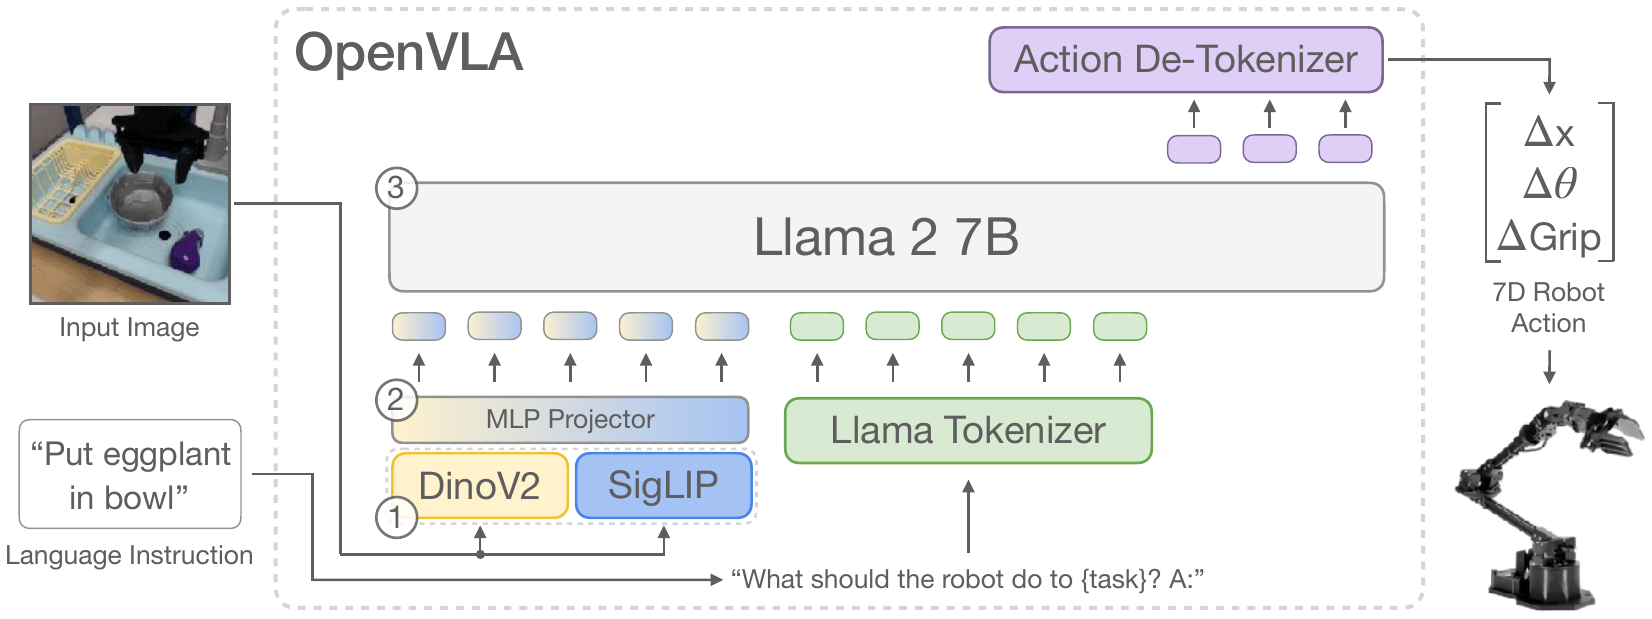

- **视觉编码器，拼接 DinoV2 与 SigLIP 特征**

- **投影器（MLP Projector），把视觉特征映射到语言嵌入空间**

- **LLM 骨干，即 Llama 2 7B 大语言模型**

### 图像 Token

为什么同时需要 **DinoV2 与 SigLIP** ？

SigLIP 提供与语言对齐的**高层语义**（"这是什么物体"），DINOv2 提供细粒度的**低层空间信息**（"它在哪里、朝什么方向"），而机器人控制恰好这两样都要。

| 编码器 | 预训练方式                   | 擅长提供                                  | 对应机器人的需求                       |
| ------ | ---------------------------- | ----------------------------------------- | -------------------------------------- |
| SigLIP | 图文对比学习（与文本对齐）   | 高层语义：物体类别、概念、与指令的对应    | "听懂指令，选对物体"（语言 grounding） |
| DINOv2 | 自监督视觉预训练（只靠图像） | 低层空间/几何结构：位置、形状、细粒度对应 | "精确对齐、抓准位置朝向"（空间推理）   |

同时，**这套双编码器是继承来的，不是 OpenVLA 单独设计的**。OpenVLA 直接采用 Prismatic-7B 作预训练骨干，SigLIP+DINOv2 是 Prismatic 自带的配置；OpenVLA 要做的是把这两个编码器连同整个骨干一起全量微调——而且论文发现 VLA 必须微调视觉编码器、不能冻结。

### 动作 Token

- action -> id：按 P1~P99 将整个区间分成 256 段，区间离散映射成 256 个离散值

- id -> token：取 Llama 词表中使用频率最低的 256 个 token，1 对 1 映射

## 结论

### 优点

- LoRA 微调追平全量微调的性能，却只训练 1.4% 参数，单卡 A100 10–15 小时即可，相比全量微调省 8 倍算力

- 只调最后一层或冻结视觉编码器都明显变差，说明视觉特征必须适配目标场景

### 局限

- 目前只支持单张图像观测；推理约 6Hz，撑不起 50Hz 的高频双臂任务

- 成功率普遍低于 90%

- 基座 VLM 规模的影响、与互联网数据联合训练的效果、什么视觉特征最适合 VLA，这些问题都没有答案。